# SIA 2026 — TP1 Multi-Agent Grid World Analysis


In [ ]:
# ─── CELL 1: Imports and configs ───────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import threading
import tracemalloc

from grid_world import GridWorld
from search import bfs, dfs, greedy, astar
from heuristics import manhattan_distance, euclidean_distance
from boards import (
    simple_multi_board,   simple_multi_configs,
    moderate_multi_board, moderate_multi_configs,
    hard_multi_board,     hard_multi_configs,
)

TIMEOUT_SECONDS       = 10
SKIP_UNINFORMED_FROM  = 5   # hopp over BFS/DFS for >= 4 agents
ALGORITHMS_UNINFORMED = {"BFS", "DFS"}

ALGORITHMS = {
    "BFS":                lambda w: bfs(w),
    "DFS":                lambda w: dfs(w),
    "Greedy (Manhattan)": lambda w: greedy(w, manhattan_distance),
    "Greedy (Euclidean)": lambda w: greedy(w, euclidean_distance),
    "A* (Manhattan)":     lambda w: astar(w, manhattan_distance),
    "A* (Euclidean)":     lambda w: astar(w, euclidean_distance),
}

ALG_COLORS = {
    "BFS":                "#4C72B0",
    "DFS":                "#DD8452",
    "Greedy (Manhattan)": "#55A868",
    "Greedy (Euclidean)": "#C44E52",
    "A* (Manhattan)":     "#8172B2",
    "A* (Euclidean)":     "#937860",
}

BOARDS = {
    "Simple":   (simple_multi_board,   simple_multi_configs),
    "Moderate": (moderate_multi_board, moderate_multi_configs),
    "Hard":     (hard_multi_board,     hard_multi_configs),
}

print("configuration done, ready to run experiments")

configuration done, ready to run experiments


In [4]:
# ─── CELL 2: Run all algorithms (run once) ─────────────────────

def run_with_timeout(fn, timeout=TIMEOUT_SECONDS):
    result = [None]
    def target():
        result[0] = fn()
    t = threading.Thread(target=target, daemon=True)
    t.start()
    t.join(timeout)
    return result[0]

def run_all(board, start, goal, n_agents):
    positions, _ = start
    world = GridWorld(board, positions, goal)
    results = {}
    for name, fn in ALGORITHMS.items():
        if name in ALGORITHMS_UNINFORMED and n_agents >= SKIP_UNINFORMED_FROM:
            print(f"    {name}: SKIPPED")
            results[name] = {
                "cost": None, "expanded": 0, "frontier": 0,
                "time_ms": 0, "memory_kb": 0, "status": "skipped"
            }
            continue

        tracemalloc.start()
        res = run_with_timeout(lambda fn=fn: fn(world))
        _, peak_memory = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        if res is None:
            print(f"    {name}: TIMEOUT (>{TIMEOUT_SECONDS}s)")
            results[name] = {
                "cost": None, "expanded": 0, "frontier": 0,
                "time_ms": TIMEOUT_SECONDS * 1000,
                "memory_kb": peak_memory / 1024, "status": "timeout"
            }
        else:
            path, exp, front, t = res
            results[name] = {
                "cost":      len(path) - 1 if path else None,
                "expanded":  exp,
                "frontier":  front,
                "time_ms":   t * 1000,
                "memory_kb": peak_memory / 1024,
                "status":    "ok" if path else "no_solution",
            }
    return results

# run all board and agent configuarations
all_data = {}
for board_name, (board, configs) in BOARDS.items():
    all_data[board_name] = {}
    for n_agents, cfg in configs.items():
        print(f"\nRunning: {board_name} — {n_agents} agents")
        all_data[board_name][n_agents] = run_all(
            board, cfg["start"], cfg["goal"], n_agents
        )

print("\nDone! all_data is ready.")


Running: Simple — 2 agents

Running: Simple — 3 agents

Running: Simple — 4 agents

Running: Moderate — 2 agents

Running: Moderate — 3 agents

Running: Moderate — 4 agents

Running: Hard — 2 agents

Running: Hard — 3 agents

Running: Hard — 4 agents
    BFS: TIMEOUT (>10s)

Done! all_data is ready.


In [ ]:
# ─── CELL 3: Result tables ──────────────────────────────────────────────

def print_table(results, title):
    print(f"\n{'='*75}")
    print(f"  {title}")
    print(f"{'='*75}")
    print(f"{'Algorithm':<22} {'Cost':>8} {'Expanded':>10} {'Frontier':>10} {'Time(ms)':>10} {'Mem(KB)':>10}")
    print("-" * 75)
    for alg, r in results.items():
        status = r.get("status", "ok")
        if status == "ok":       cost = str(r["cost"])
        elif status == "timeout": cost = "TIMEOUT"
        elif status == "skipped": cost = "SKIPPED"
        else:                     cost = "NO SOL"
        print(f"{alg:<22} {cost:>8} {r['expanded']:>10} {r['frontier']:>10} "
              f"{r['time_ms']:>10.1f} {r['memory_kb']:>10.1f}")

for board_name, agent_data in all_data.items():
    for n_agents, results in agent_data.items():
        print_table(results, f"{board_name} — {n_agents} agents")


  Simple — 2 agenter
Algorithm                  Cost   Expanded   Frontier   Time(ms)    Mem(KB)
---------------------------------------------------------------------------
BFS                          16        407         20        4.8       75.4
DFS                          43         45         22        0.4        9.3
Greedy (Manhattan)           28         32         22        2.2        9.2
Greedy (Euclidean)           16         18         27        1.2        9.4
A* (Manhattan)               16         96         86        1.9       40.0
A* (Euclidean)               16        150         77        3.0       35.6

  Simple — 3 agenter
Algorithm                  Cost   Expanded   Frontier   Time(ms)    Mem(KB)
---------------------------------------------------------------------------
BFS                          23       5282        376       66.1     1760.5
DFS                         101        157         58        0.7       25.7
Greedy (Manhattan)           41        145  

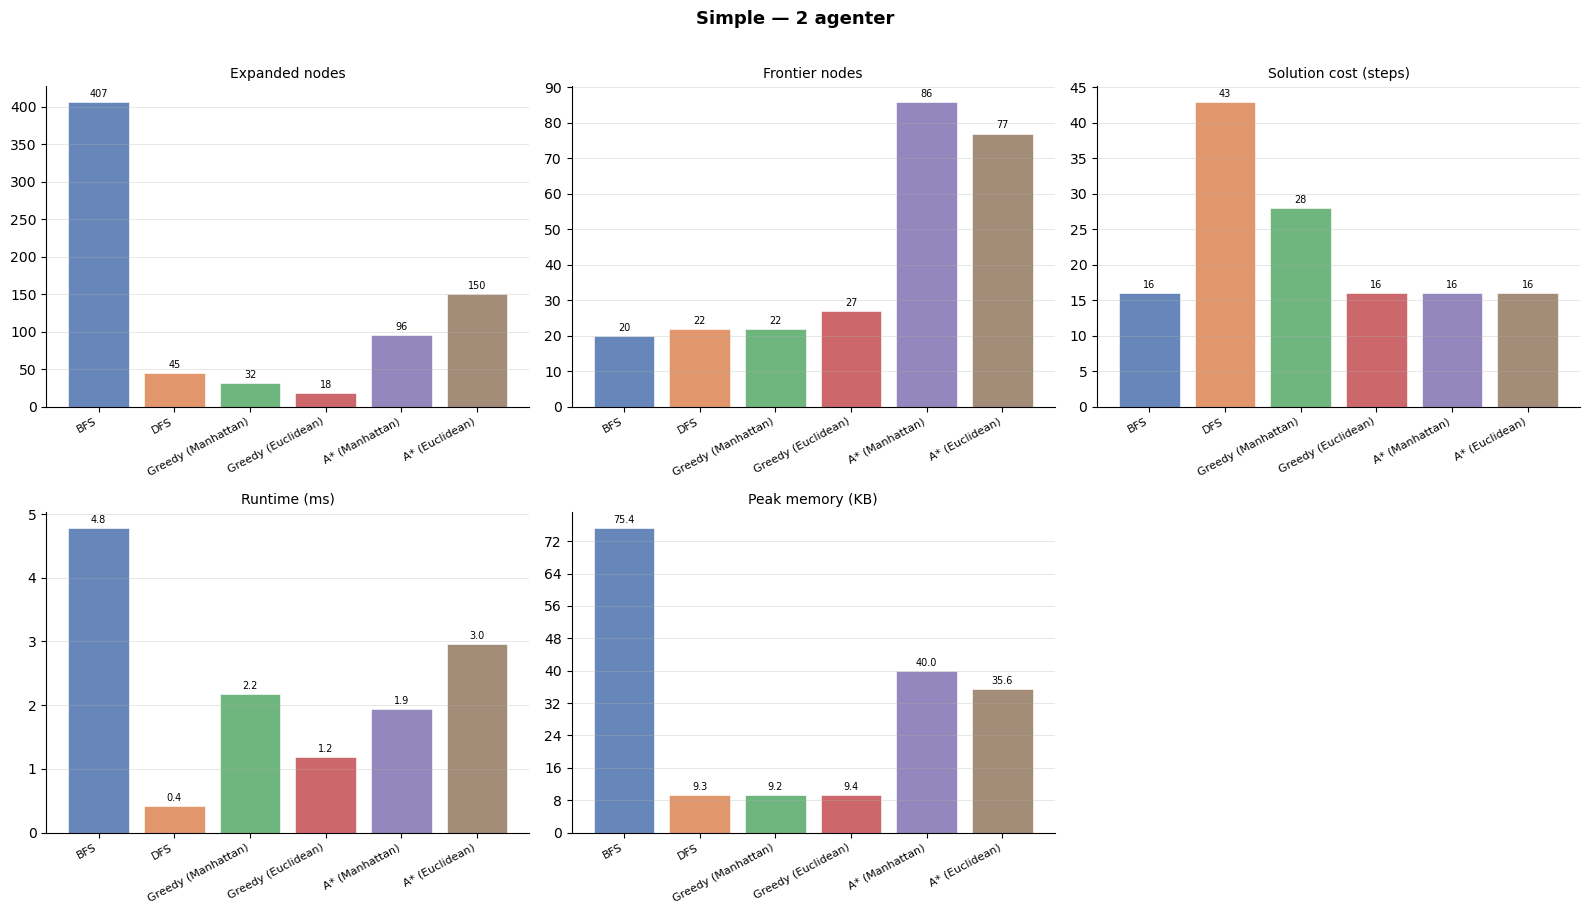

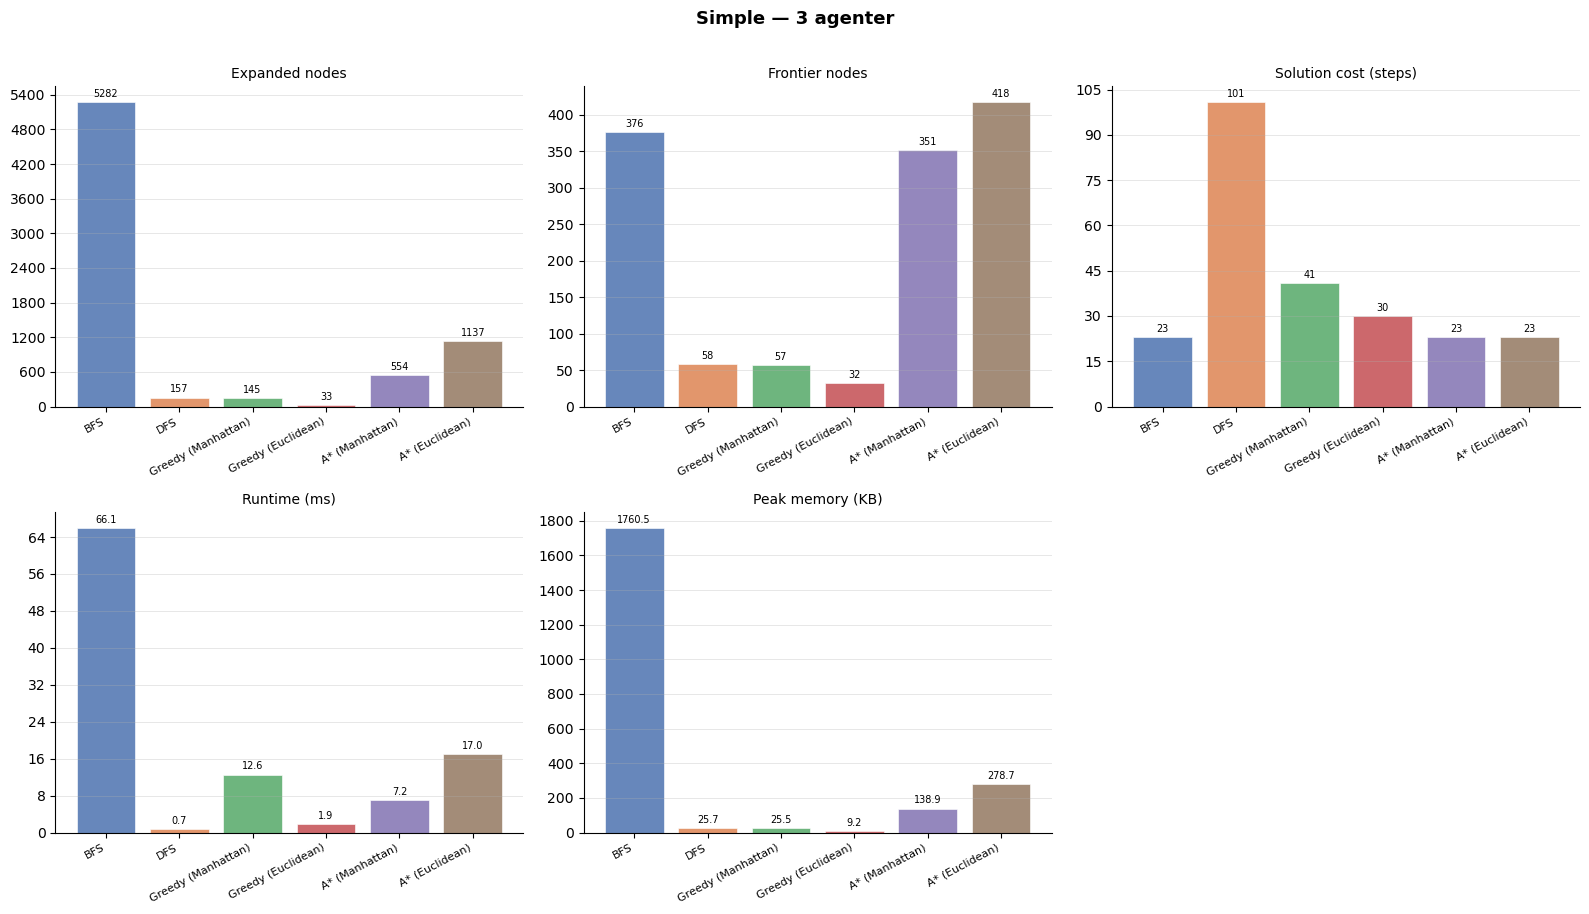

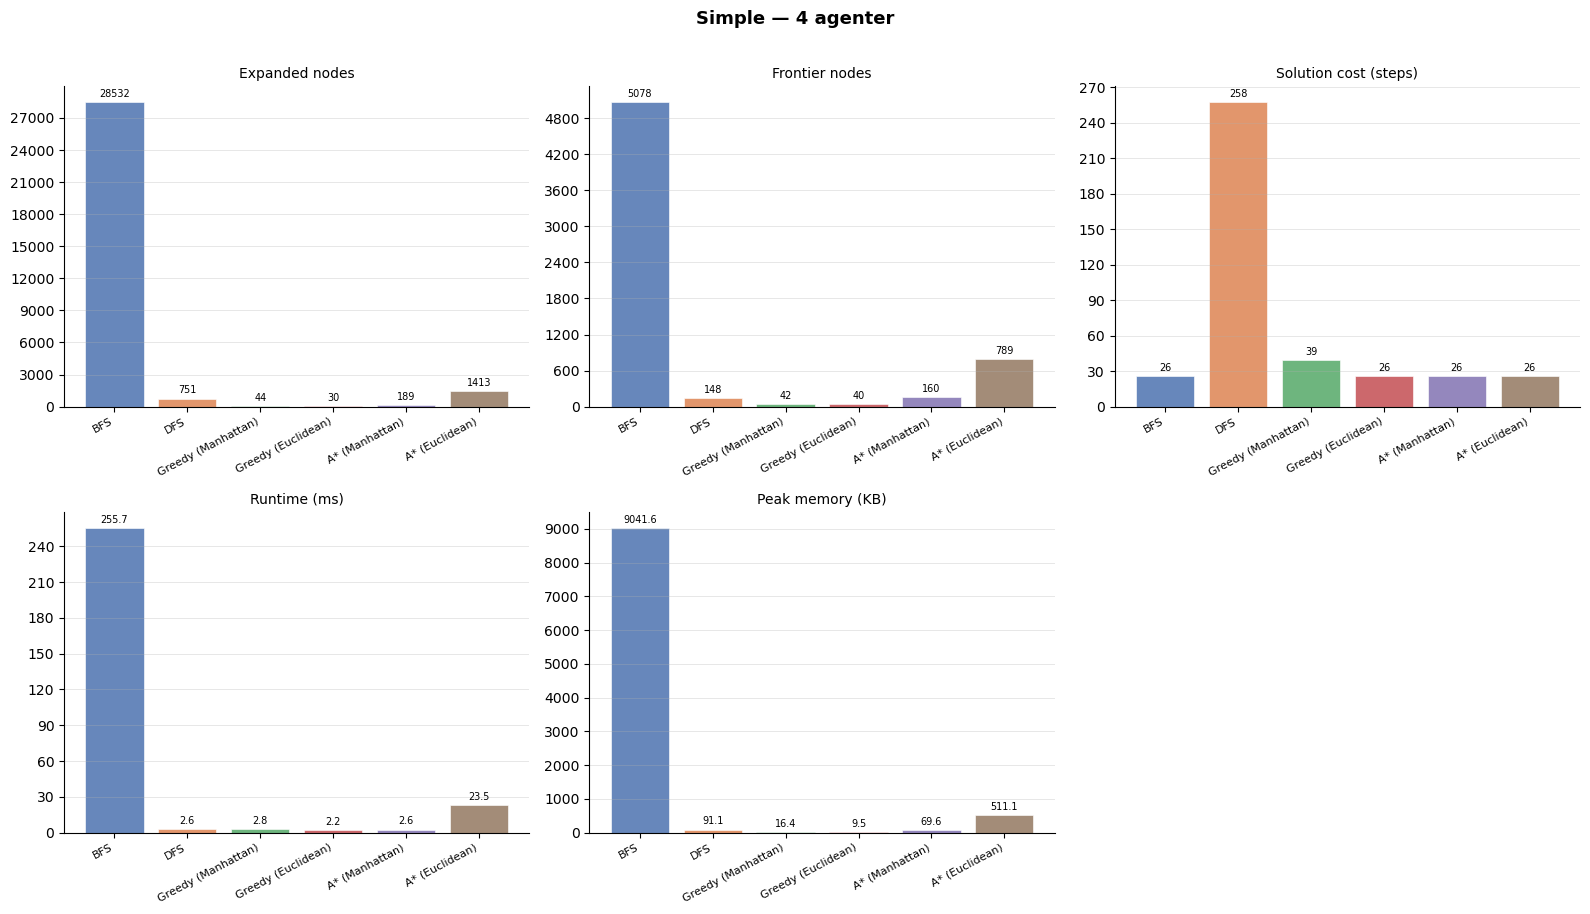

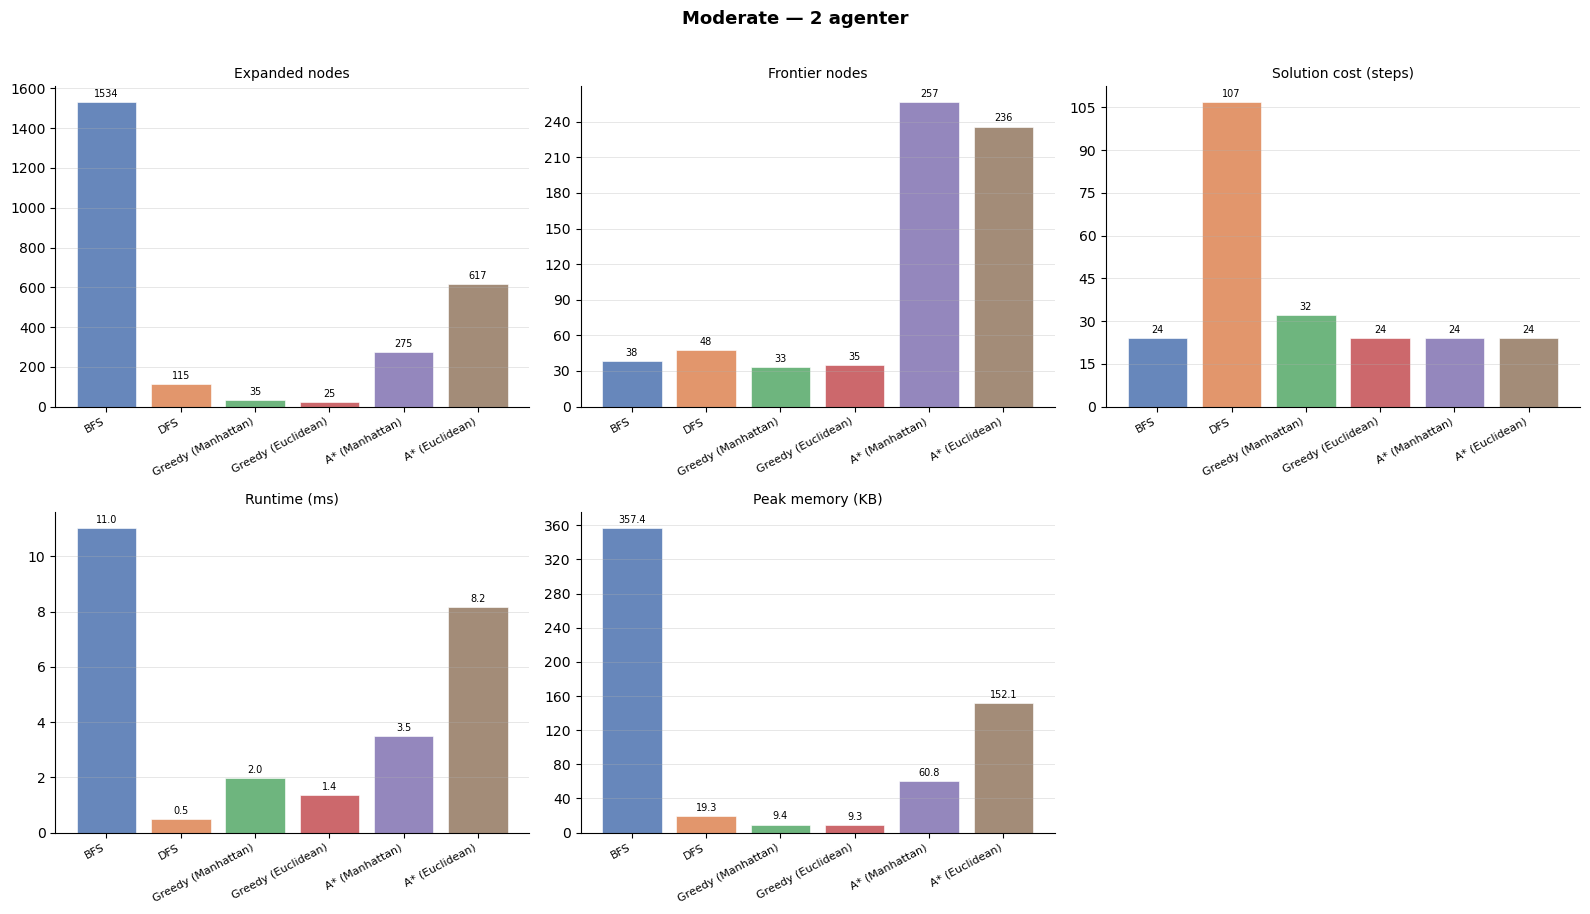

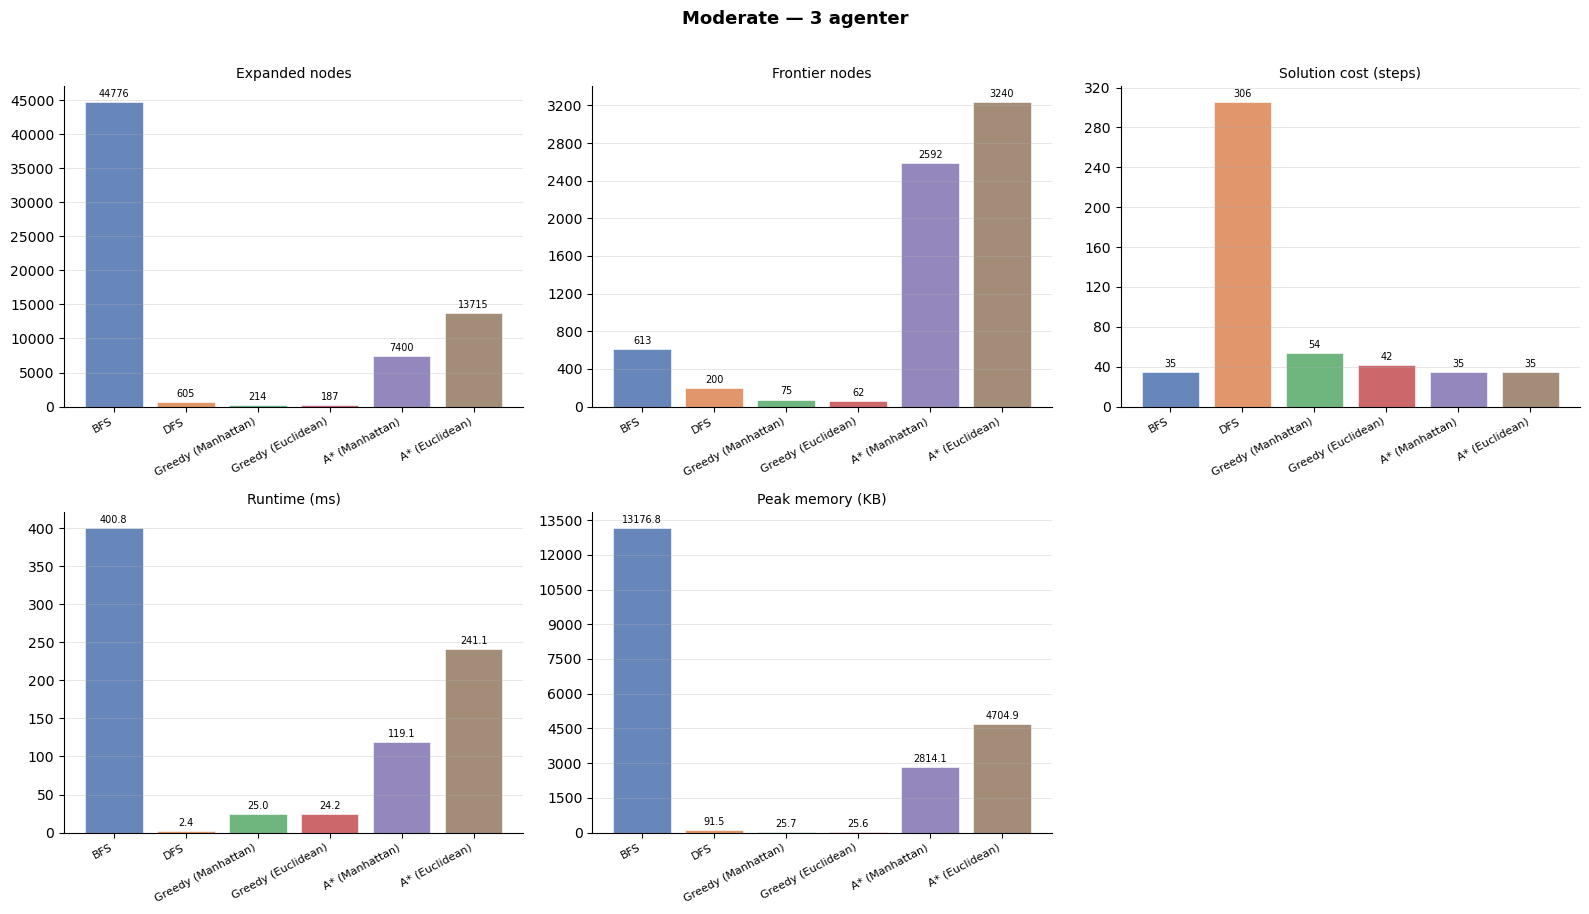

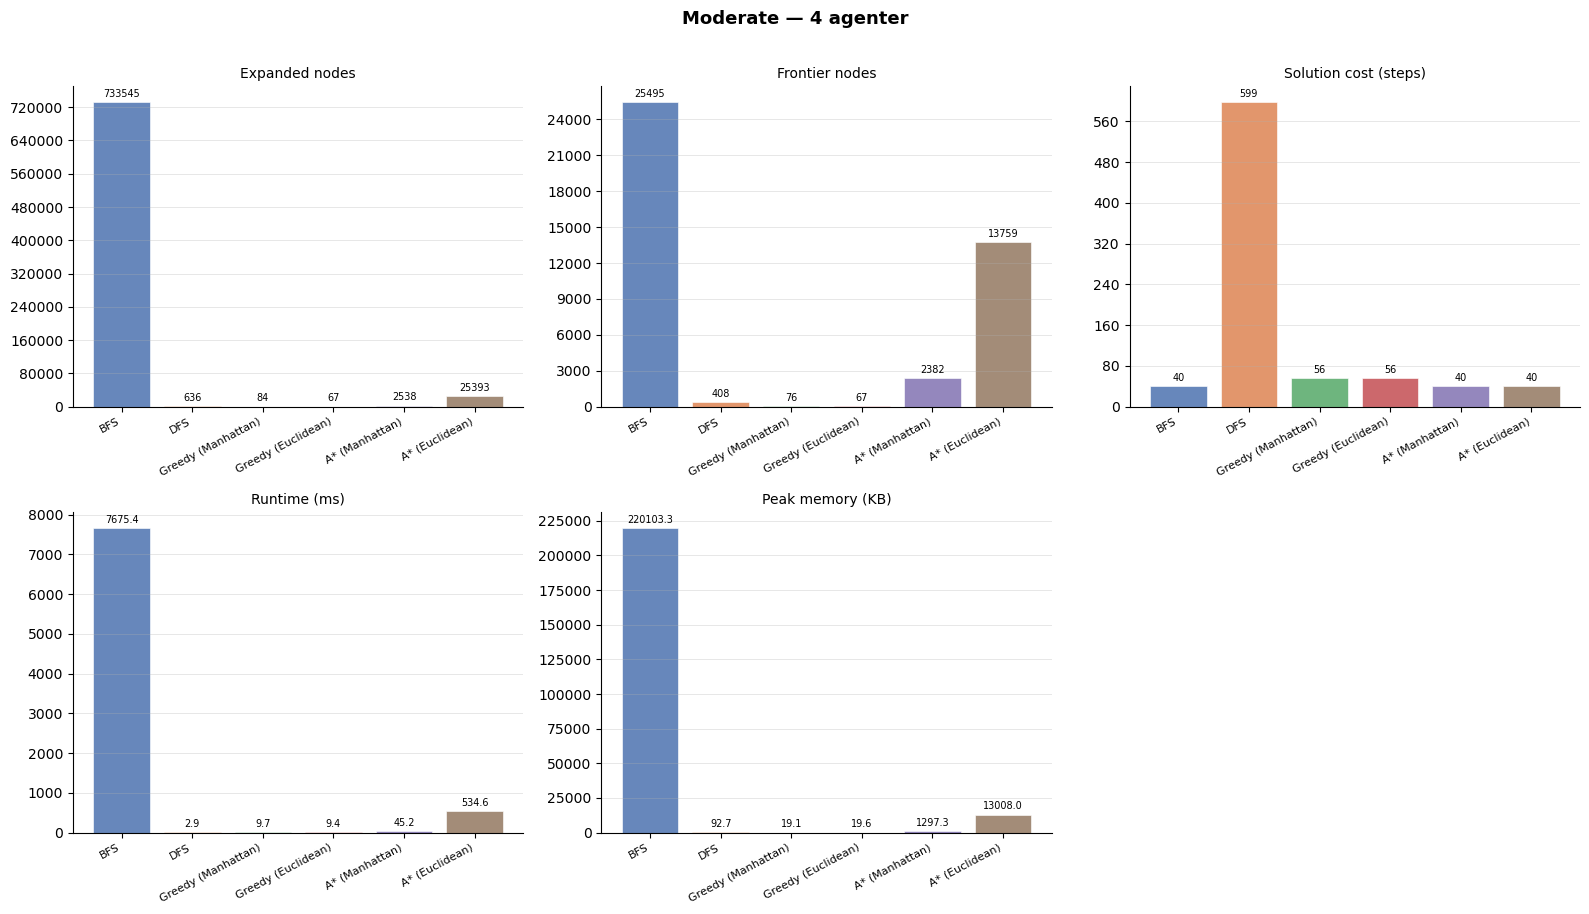

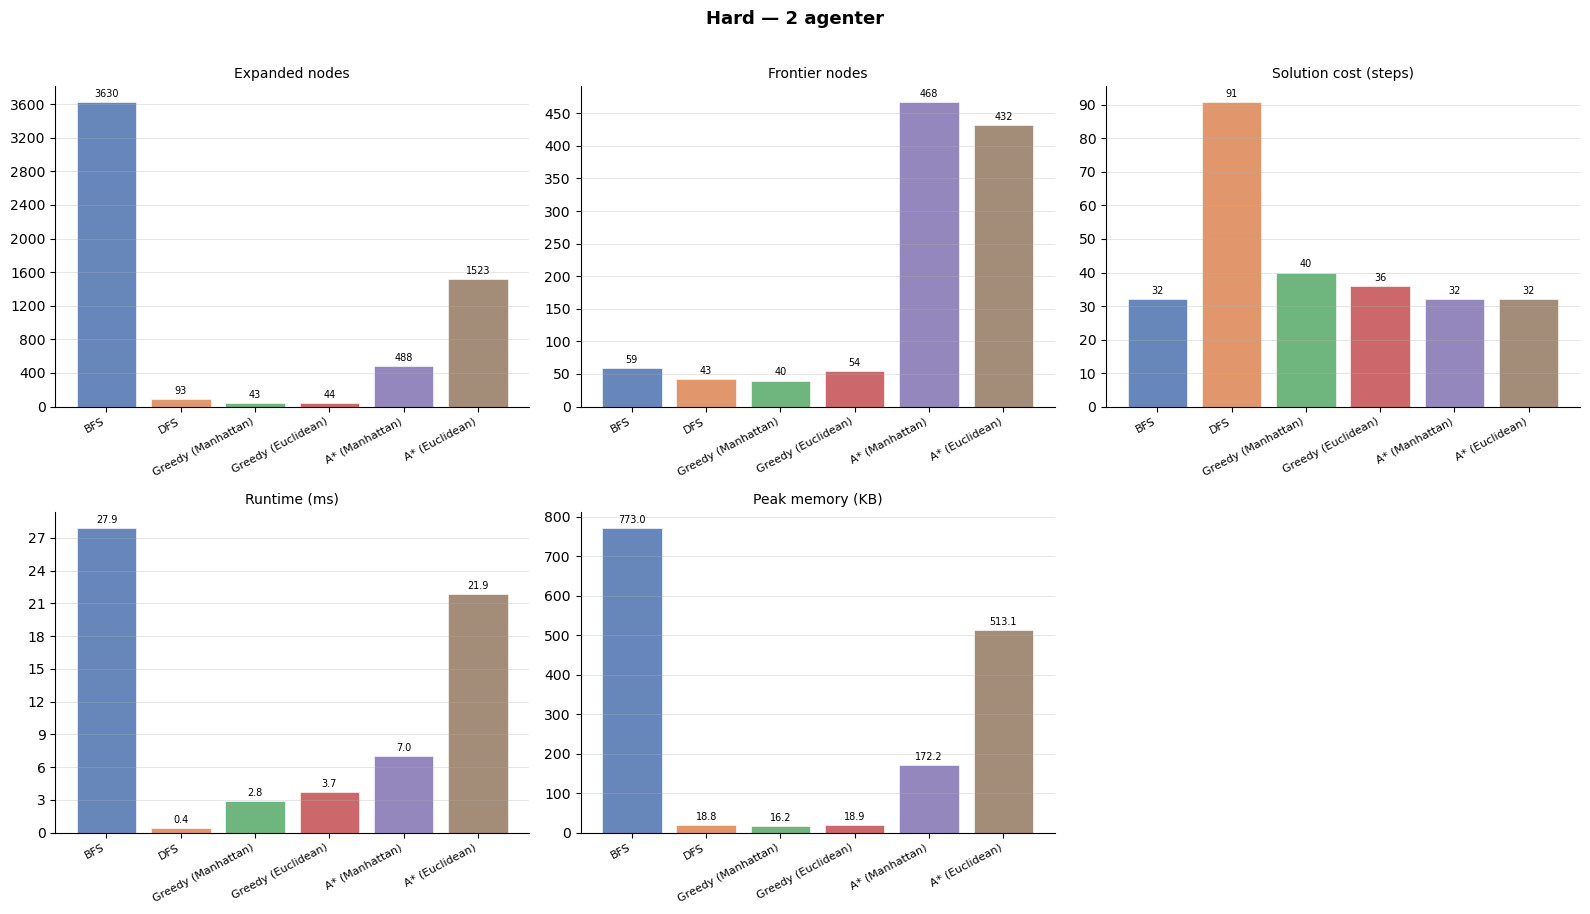

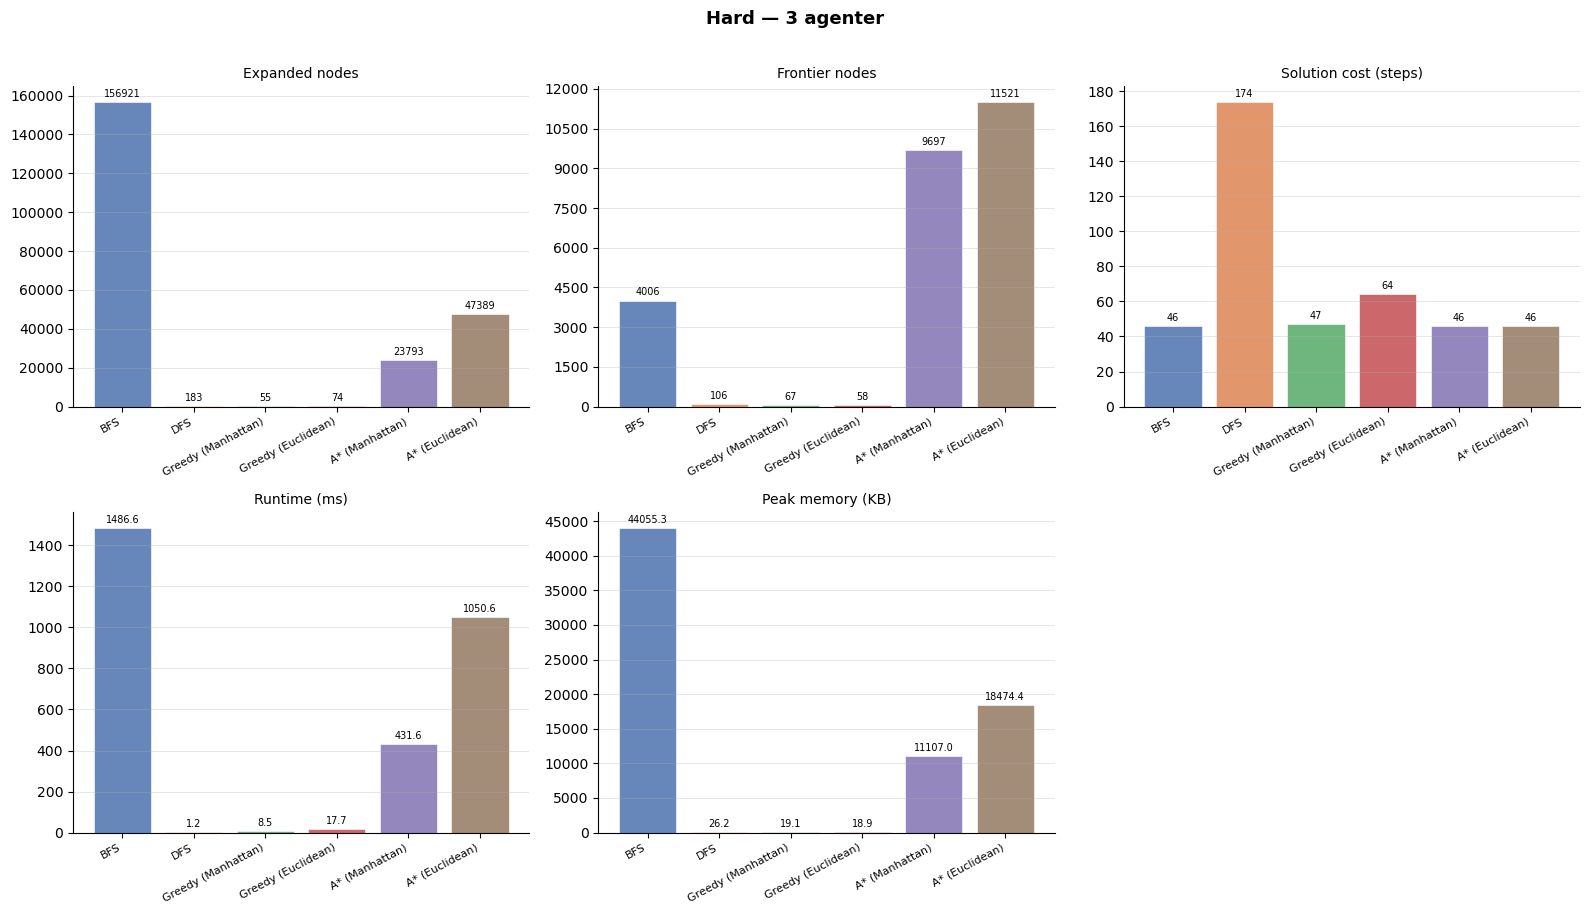

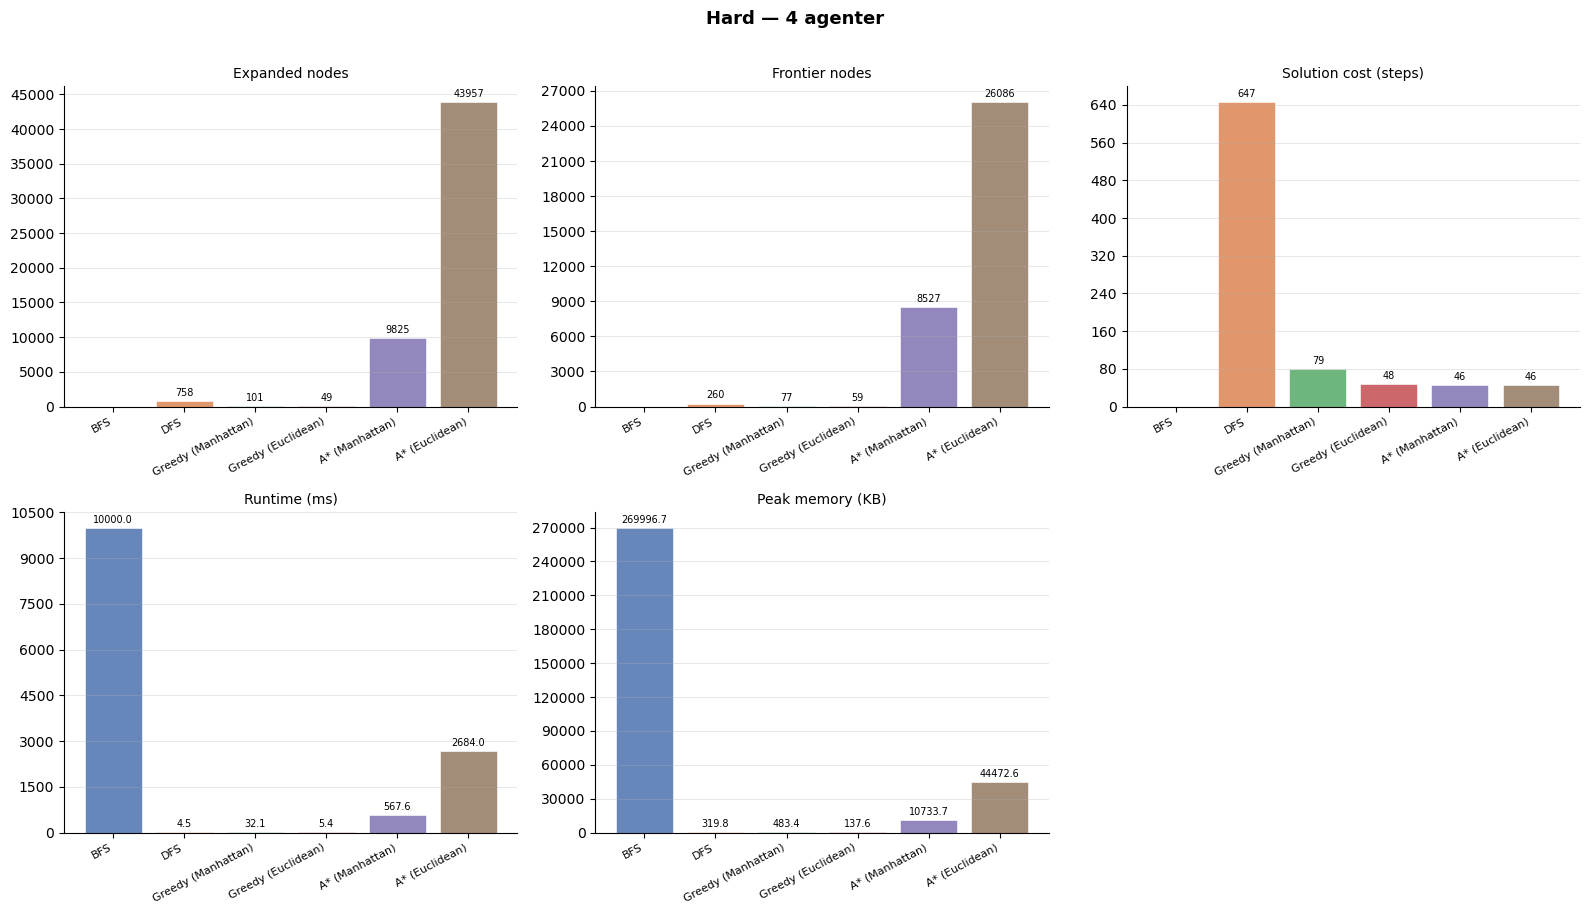

In [ ]:
# ─── CELL 4: Bar charts per board ognumber of agent ─────────────────────

def plot_bar(results, title):
    algs       = list(results.keys())
    bar_colors = [ALG_COLORS[a] for a in algs]
    x          = np.arange(len(algs))

    metrics = {
        "Expanded nodes":        [results[a]["expanded"]  for a in algs],
        "Frontier nodes":        [results[a]["frontier"]  for a in algs],
        "Solution cost (steps)": [results[a]["cost"] or 0 for a in algs],
        "Runtime (ms)":          [results[a]["time_ms"]   for a in algs],
        "Peak memory (KB)":      [results[a]["memory_kb"] for a in algs],
    }

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.01)
    axes = axes.flatten()

    for ax, (metric_name, values) in zip(axes, metrics.items()):
        bars = ax.bar(x, values, color=bar_colors, alpha=0.85, edgecolor="white", linewidth=0.5)
        ax.set_title(metric_name, fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(algs, rotation=28, ha="right", fontsize=8)
        ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", alpha=0.3, linewidth=0.7)
        for bar, val in zip(bars, values):
            if val == 0: continue
            label = f"{val:.1f}" if metric_name in ("Runtime (ms)", "Peak memory (KB)") else str(val)
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + max(values) * 0.01,
                    label, ha="center", va="bottom", fontsize=7)

    axes[-1].set_visible(False)
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_').replace('/', '_')}_bar.png", dpi=150, bbox_inches="tight")
    plt.show()

for board_name, agent_data in all_data.items():
    for n_agents, results in agent_data.items():
        plot_bar(results, f"{board_name} — {n_agents} agents")

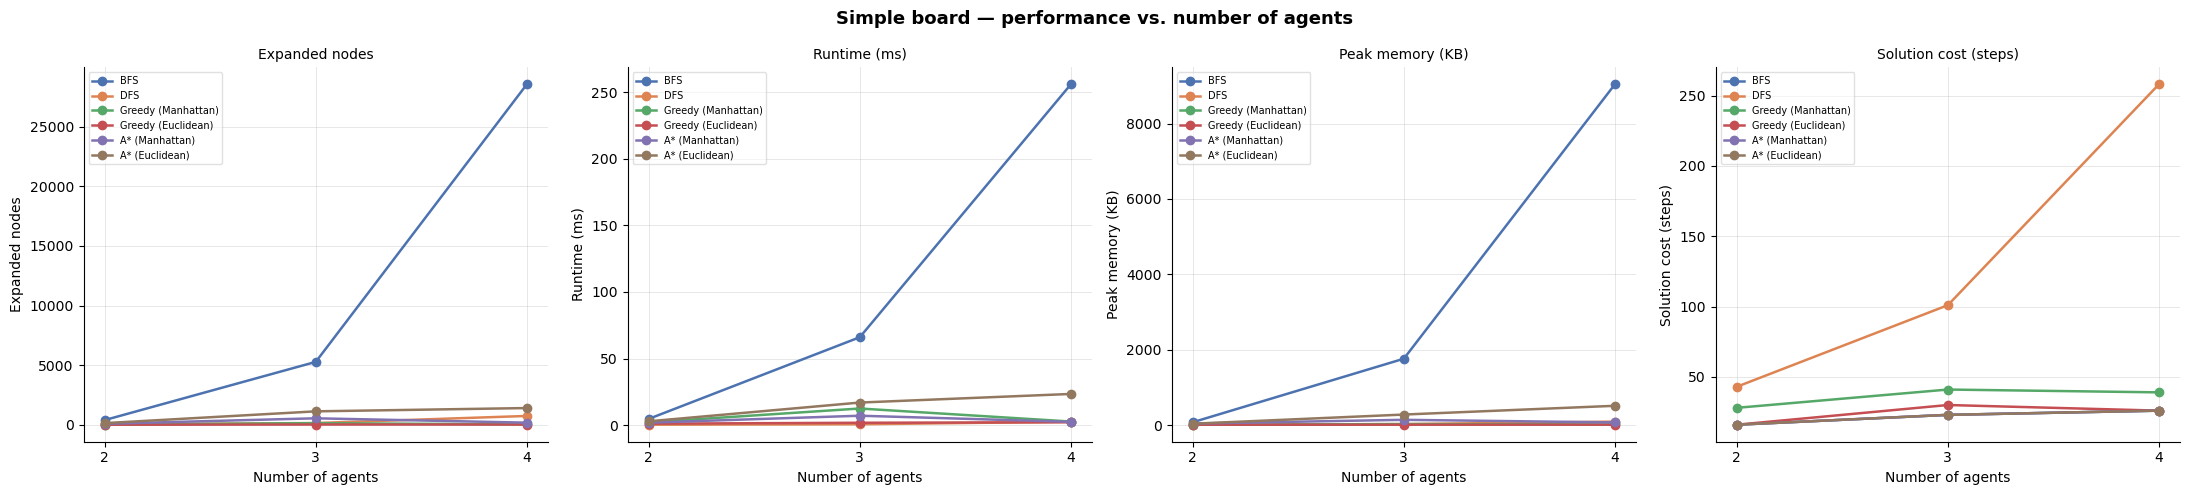

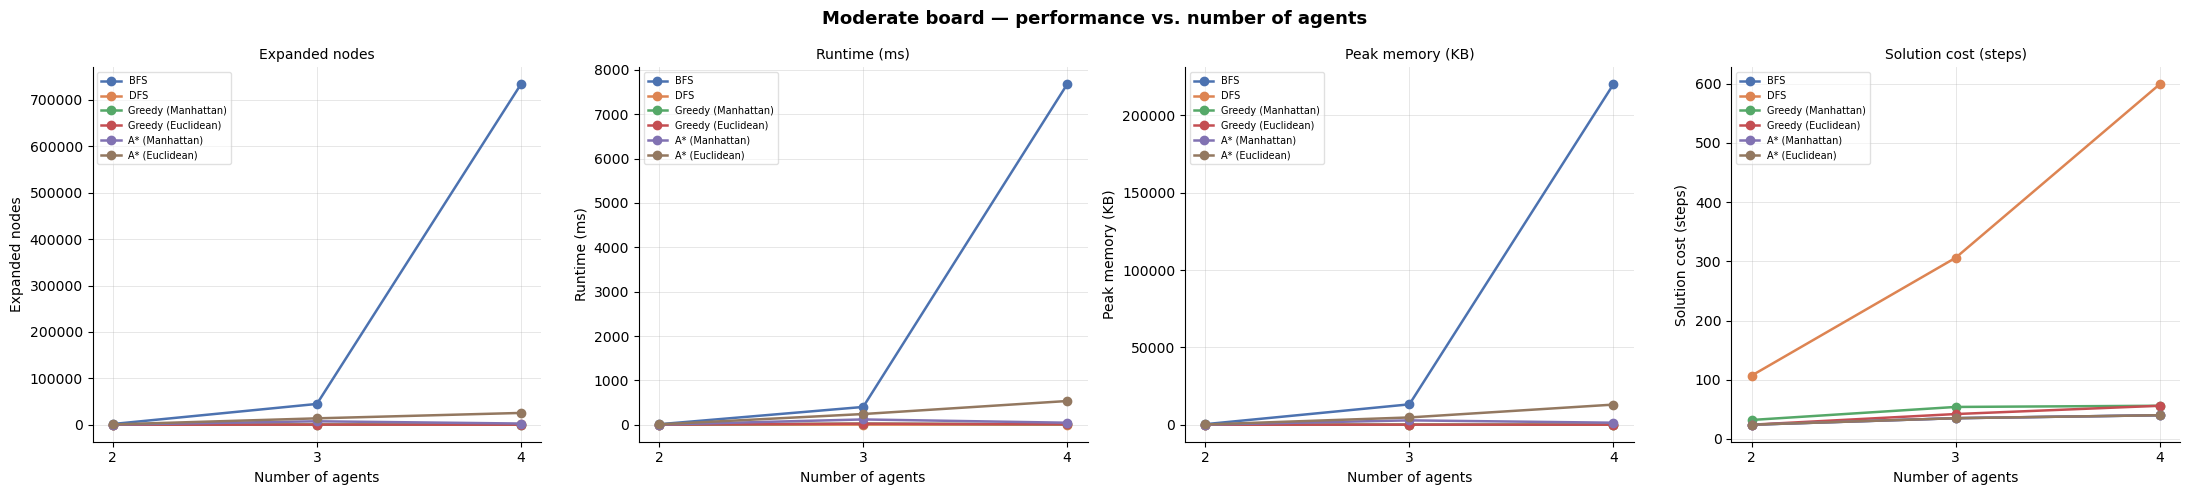

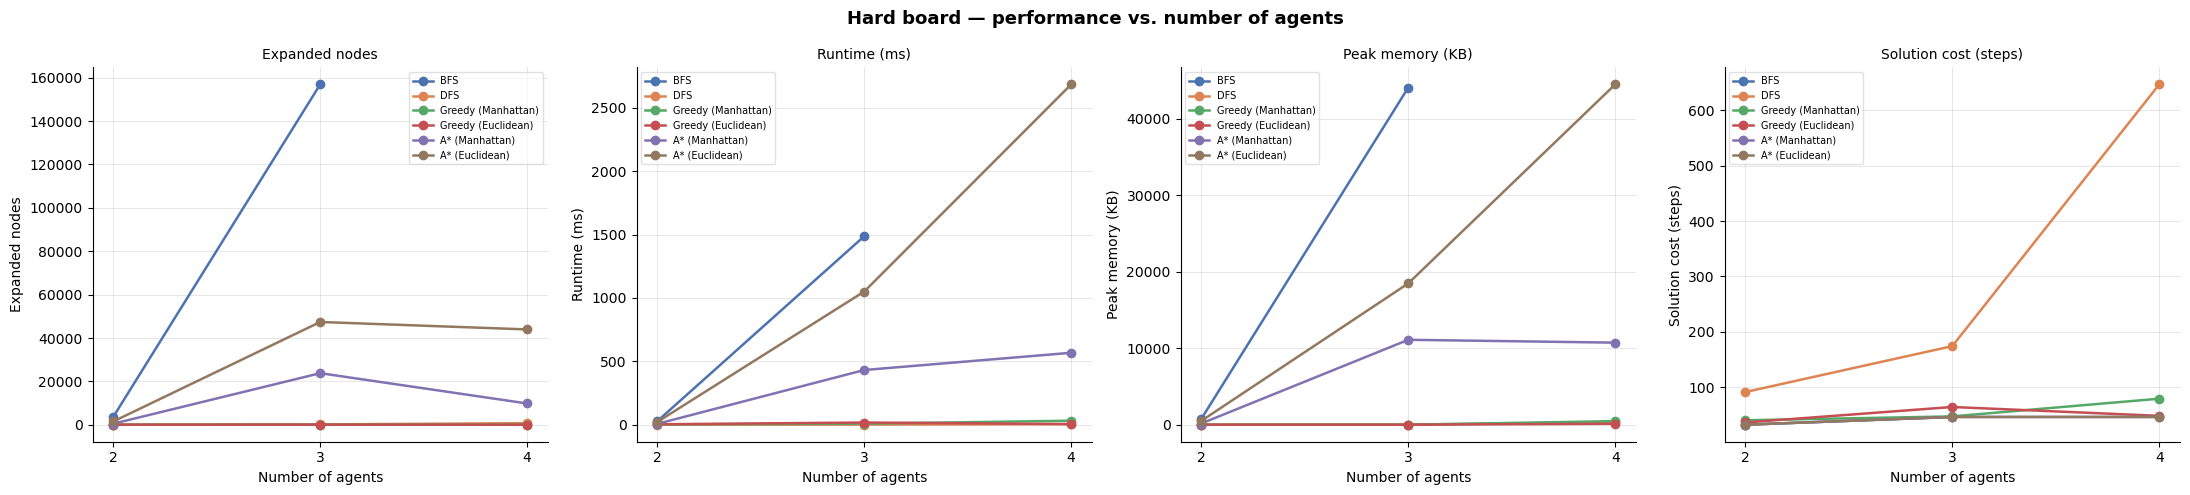

In [7]:
# ─── CELL 5: Line charts — performance vs. number of agents ───────────────────

def plot_scaling(all_data):
    for board_name, agent_data in all_data.items():
        agent_counts = sorted(agent_data.keys())

        metric_keys   = ["expanded", "time_ms", "memory_kb", "cost"]
        metric_labels = ["Expanded nodes", "Runtime (ms)", "Peak memory (KB)", "Solution cost (steps)"]

        fig, axes = plt.subplots(1, 4, figsize=(22, 5))
        fig.suptitle(
            f"{board_name} board — performance vs. number of agents",
            fontsize=13, fontweight="bold"
        )

        for alg, color in ALG_COLORS.items():
            for ax, key, label in zip(axes, metric_keys, metric_labels):
                values = [
                    agent_data[n][alg][key]
                    if agent_data[n][alg]["status"] == "ok"
                    else np.nan
                    for n in agent_counts
                ]
                ax.plot(agent_counts, values, marker="o", label=alg,
                        color=color, linewidth=1.8, markersize=6)

        for ax, label in zip(axes, metric_labels):
            ax.set_title(label, fontsize=10)
            ax.set_xlabel("Number of agents")
            ax.set_ylabel(label)
            ax.set_xticks(agent_counts)
            ax.legend(fontsize=7, framealpha=0.6)
            ax.spines[["top", "right"]].set_visible(False)
            ax.grid(alpha=0.3, linewidth=0.7)

        plt.tight_layout()
        plt.savefig(f"{board_name}_scaling_line.png", dpi=150, bbox_inches="tight")
        plt.show()

plot_scaling(all_data)